--- CHARGEMENT DU DATASET ---
✓ Fichier ZIP trouvé et utilisé : Student Mental health (2).zip
Dimensions : 101 lignes et 11 colonnes

--- EXERCICE 4 : HISTOGRAMME DES CGPA ---


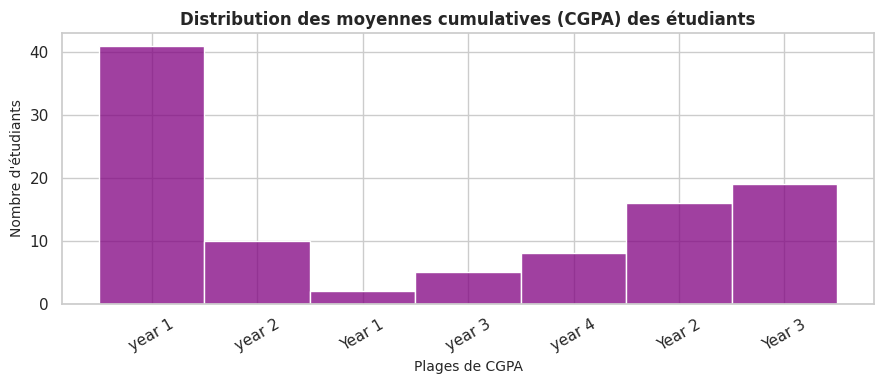



--- EXERCICE 5 : ANXIÉTÉ SELON LE SEXE ---


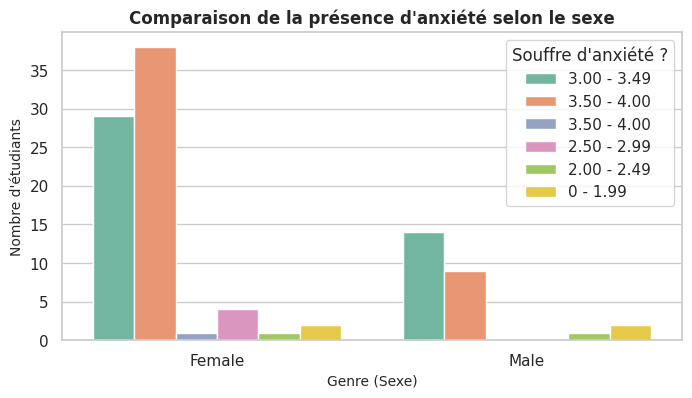



--- EXERCICE 6 : ÂGE VS CRISES DE PANIQUE ---


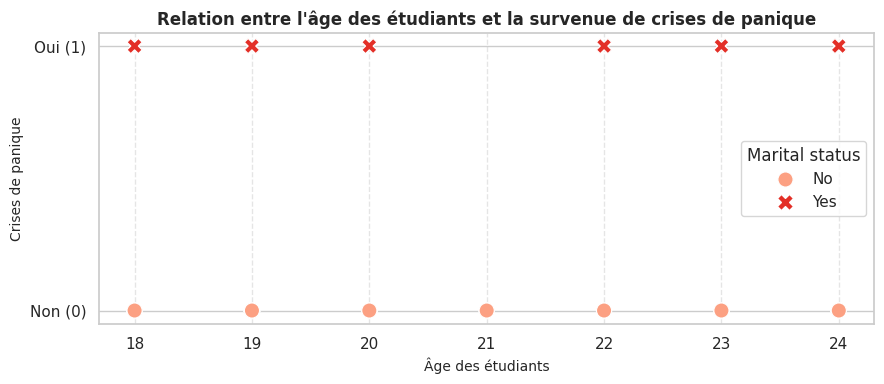

In [6]:
import zipfile
import io
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration esthétique globale des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# =====================================================================
# 1. RÉCUPÉRATION AUTOMATIQUE DU FICHIER DÉJÀ CHARGÉ
# =====================================================================
print("--- CHARGEMENT DU DATASET ---")

# Recherche du fichier ZIP dans l'environnement actuel de Colab
fichiers_zip = [f for f in os.listdir('.') if 'Student Mental health' in f and f.endswith('.zip')]

if fichiers_zip:
    nom_zip = fichiers_zip[-1] # Sélectionne le fichier le plus récent
    print(f"✓ Fichier ZIP trouvé et utilisé : {nom_zip}")

    with zipfile.ZipFile(nom_zip, 'r') as z:
        liste_fichiers = z.namelist()
        csv_interne = [f for f in liste_fichiers if f.endswith('.csv')][0]

        with z.open(csv_interne) as f:
            df_mental = pd.read_csv(io.BytesIO(f.read()), encoding='latin-1')

    print(f"Dimensions : {df_mental.shape[0]} lignes et {df_mental.shape[1]} colonnes\n")

    # Assignation stricte par index de colonne
    genre_col = df_mental.columns[1]
    age_col = df_mental.columns[2]
    cgpa_col = df_mental.columns[4]
    anxiete_col = df_mental.columns[5]
    panique_col = df_mental.columns[6]

    # Nettoyage de la colonne CGPA
    df_mental[cgpa_col] = df_mental[cgpa_col].astype(str).str.strip()

    # =====================================================================
    # 🌟 EXERCICE 4 : Distribution des moyennes cumulatives (Histogramme)
    # =====================================================================
    print("--- EXERCICE 4 : HISTOGRAMME DES CGPA ---")
    plt.figure(figsize=(9, 4))
    sns.histplot(data=df_mental, x=cgpa_col, color='purple', kde=False)
    plt.title("Distribution des moyennes cumulatives (CGPA) des étudiants", fontsize=12, fontweight='bold')
    plt.xlabel("Plages de CGPA", fontsize=10)
    plt.ylabel("Nombre d'étudiants", fontsize=10)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

    # =====================================================================
    # 🌟 EXERCICE 5 : Comparaison des niveaux d'anxiété selon le sexe
    # =====================================================================
    print("--- EXERCICE 5 : ANXIÉTÉ SELON LE SEXE ---")
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_mental, x=genre_col, hue=anxiete_col, palette="Set2")
    plt.title("Comparaison de la présence d'anxiété selon le sexe", fontsize=12, fontweight='bold')
    plt.xlabel("Genre (Sexe)", fontsize=10)
    plt.ylabel("Nombre d'étudiants", fontsize=10)
    plt.legend(title="Souffre d'anxiété ?")
    plt.show()
    print("\n" + "="*50 + "\n")

    # =====================================================================
    # 🌟 EXERCICE 6 : Relation entre l'âge et les crises de panique (Scatter)
    # =====================================================================
    print("--- EXERCICE 6 : ÂGE VS CRISES DE PANIQUE ---")
    # Conversion propre des réponses (Oui/Non) en valeurs numériques (1/0)
    df_mental['Panic_Numeric'] = df_mental[panique_col].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

    plt.figure(figsize=(9, 4))

    # CORRECTION ICI : Remplacement de 'crimson_r' par la palette standard 'Reds'
    sns.scatterplot(
        data=df_mental,
        x=age_col,
        y='Panic_Numeric',
        hue=panique_col,
        style=panique_col,
        s=120,
        palette="Reds"
    )
    plt.yticks([0, 1], ['Non (0)', 'Oui (1)'])
    plt.title("Relation entre l'âge des étudiants et la survenue de crises de panique", fontsize=12, fontweight='bold')
    plt.xlabel("Âge des étudiants", fontsize=10)
    plt.ylabel("Crises de panique", fontsize=10)
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print("Erreur : Aucun fichier contenant 'Student Mental health' n'a été trouvé dans l'espace Colab.")

🌟 Exercice 1 : Comprendre la visualisation des données
(À mettre dans une cellule Markdown ou textuelle dans votre notebook)

Importance de la visualisation : Elle est essentielle car le cerveau humain traite les informations visuelles beaucoup plus rapidement que les lignes de texte ou de chiffres d'un tableau. Elle permet de détecter instantanément des tendances, des anomalies (outliers), des distributions ou des corrélations cachées dans les données brutes.

Utilité d'un graphique linéaire : Un graphique linéaire est principalement utilisé pour représenter l'évolution d'une variable numérique en fonction d'une variable continue (le plus souvent le temps). Il permet de visualiser facilement des trajectoires, des cycles, des augmentations ou des baisses sur des données chronologiques (séries temporelles).